<a href="https://colab.research.google.com/github/wasimnawaz1/NLP_lectures/blob/main/Introduction_to_NLP_(Week_5)_naive_bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CS438  Natural Language Processing (NLP)** (Week 5)
https://github.com/wasimnawaz1/NLP_lectures

### Instructor: Dr. M. Wasim Nawaz (Associate Professor, Artificial Intelligence)
    📞+92-331-4180565  📧 wasim.nawaz@umt.edu.pk

Office: SST 1 - 506
Office Hours (Ramadan): 09:00 am to 10:00 am (Monday to Friday)

Office Hours: 10:00 am to 12:00 pm (Monday to Friday)



### Text Classification

Text classification is assigning a **label** from a fixed set of categories to a piece of text.

Common applications:
- Assigning subject categories, topics, or genres
- **Spam detection** (spam vs. ham)
- **Authorship identification** (who wrote this?)
- **Age / gender identification**
- **Language identification**
- **Sentiment analysis** (positive vs. negative)

### Spam/Ham Example

Look at the following email.


```
Subject: Important Notice


Dear Student,

Great News! Your Stanford University account has been selected for a special update and verification process.

Due to recent security improvements, you are required to confirm your account information immediately to avoid suspension of your university email and services.

Please click the link below and complete the verification within 24 hours:

http://123contactform.com/stanford-verification

Failure to complete this process may result in temporary deactivation of your account.

Thank you for your prompt attention.

Sincerely,
Stanford University IT Services
```
This email **looks** like it is from Stanford University but links to a suspicious domain (`123contactform.com`).

- Key red flags: urgent subject line (`Important notice!`), excitement phrase (`Great News!`), and a non-Stanford URL.

A classifier must learn to detect these patterns automatically from labelled examples.

### Gender Identification Example (Male or female author?)

Given two passages:

1. By 1925 present-day Vietnam was divided into three parts under French colonial rule. The southern region embracing Saigon and the Mekong delta was the colony of Cochin-China; the central area with its imperial capital at Hue was the protectorate of Annam...

2. Clara never failed to be astonished by the extraordinary felicity of her own name. She found it hard to trust herself to the mercy of fate, which had managed over the years to convert her greatest shame into one of her greatest assets...

S. Argamon, M. Koppel, J. Fine, A. R. Shimoni, 2003. “Gender, Genre, and Writing Style in Formal Written Texts”, Text, volume 23, number 3, pp. 321–346

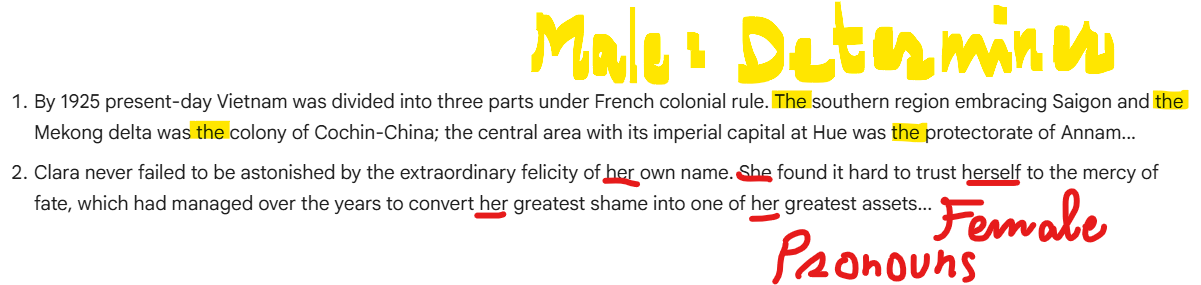

### Sentiment Analysis Example

| Review | Sentiment |
|--------|----------|
| *"…zany characters and richly applied satire, and some great plot twists"* | Positive |
| *"It was pathetic. The worst part about it was the boxing scenes…"* |  Negative |
| *"…awesome caramel sauce and sweet toasty almonds. I love this place!"* |  Positive |
| *"…awful pizza and ridiculously overpriced…"* |  Negative |

### Classification Methods

#### 1. Hand-coded Rules
- Rules based on combinations of words or other features
- Example (spam): `black-list-address OR ("dollars" AND "have been selected")`
- Accuracy can be high **if rules are carefully refined by an expert**
- ❌ Building and maintaining these rules is **expensive**

#### 2. Supervised Machine Learning

**Input:**
- A document $d$, a fixed set of classes $C = \{c_1, \ldots, c_J\}$
- A training set of $m$ hand-labelled documents: $(d_1, c_1), \ldots, (d_m, c_m)$

**Output:** A learned classifier: $d \rightarrow c \in C$

### Types of Classifiers

- Naïve Bayes
- k-NN
- Random Forests
- Logistic Regression
- SVMs
- Perceptron, Neural Networks and more.

| Type | Description | Example |
|------|-------------|--------|
| **Generative** | Builds a probability model for each class | Naïve Bayes |
| **Discriminative** | Learns the most useful features to separate classes | Logistic Regression |

### Naïve Bayes Classification

Naïve Bayes is a classification method based on **Bayes' Rule**. It makes a simple (naïve) assumption of **independence of features** and can be used with very simple representation of documents, such as
- **Bag of Words**
- **TF-IDF**
- **N-grams**

### Review of Probability Concepts for Applying Naïve Bayes to Text Classification Task

#### Probability

**Definition:** Probability measures how likely an event is.

$$
P(A) = \frac{\text{Number of favorable outcomes}}{\text{Total outcomes}}
$$

**Text Example:**  
Suppose in 100 emails, 40 are spam.

$$
P(\text{Spam}) = \frac{40}{100} = 0.4
$$



### Conditional Probability

**Definition:** Probability of event A given B has occurred.

$$
P(A|B) = \frac{P(A \cap B)}{P(B)}
$$

**Text Example:**  
Out of 40 spam emails, 30 contain the word "win".

$$
P(\text{win}|\text{spam}) = \frac{30}{40} = 0.75
$$



### Independence of Events

**Definition:** Two events are independent if one does not affect the other.

$$
P(A|B) = P(A)
$$
Therefore:
$$
P(A|B) = P(A) = \frac{P(A \cap B)}{P(B)}
$$
Or
$$
P(A)P(B) = P(A \cap B)
$$







### Text Example

For a document $d$ = "win money now"

Let
$$
w_i = \text{each word in the document}
$$
So
$$
w_1 = \text{"win"}
$$

$$
w_2 = \text{"money"}
$$

$$
w_3 = \text{"now"}
$$

So the formula becomes:

$$
P(d \mid c) = P(\text{win, money, now} \mid c)
$$
Or
$$
P(d \mid c) = P(\text{win} \mid c) \cdot P(\text{money} \mid c) \cdot P(\text{now} \mid c)
$$

> Each word is assumed independent given the class. Therefore, we multiply probabilities to estimate how likely the document is for a class because of the **Naïve assumption (independence)**:

> **Note**: In real text, words are NOT truly independent.


### Important Note for Bag of Words Model

- Order does **not matter**
- Words can **repeat**

**Example:**

$d$ = "win win money"


$$
P(d \mid c) = P(\text{win} \mid c)^2 \cdot P(\text{money} \mid c)
$$



### Binomial Distribution

**Definition:** Models number of successes $k$ in $n$ independent Bernoulli  trials.

- A Bernoulli trial is a random experiment with exactly two possible outcomes—"success" ($p$) and "failure" ($q=1-p$). The probability of success remains constant across independent trials.

- We want to find the probability of exactly $k$ successes in $n$ trials. Therefore, there must be $n - k$ failures.

- Because the trials are independent, the probability of one specific sequence  
(e.g., $k$ successes followed by $n - k$ failures: $SS...S\ FF...F$) is:
$$
P(\text{specific sequence}) = p \times p \times \cdots \times p \times (1 - p) \times \cdots \times (1 - p)
$$

$$
= p^k (1 - p)^{n - k}
$$

- The $k$ successes can occur in any order across the $n$ trials. Thus, the number of different ways to arrange $k$ successes in $n$ trials is given by the binomial coefficient:
$$
\binom{n}{k} = \frac{n!}{k!(n - k)!}
$$

The probability mass function for the Binomial distribution becomes:
$$
P(X = k) = \binom{n}{k} p^k (1 - p)^{n-k}
$$

**Text Example:**  
Suppose probability of spam = 0.4, and we observe 5 emails.  
Probability that exactly 3 are spam:

$$
P(X=3) = \binom{5}{3} (0.4)^3 (0.6)^2
$$



### Multinomial Distribution

**Definition:** Extension / generalization of Binomial for multiple categories.

- For example, it models the probability of counts for each side of a $k$-sided die rolled $n$ times.

- For $n$ independent trials each of which leads to a success for exactly one of $k$ categories, with each category having a given fixed success probability, the multinomial distribution gives the probability of any particular combination of numbers of successes for the various categories.

$$
P(x_1, x_2, ..., x_k) =
\frac{n!}{x_1! x_2! \cdots x_k!}
\prod_{i=1}^{k} p_i^{x_i}
$$

Where:
- $x_i$ = count of category $i$
- $p_i$ = probability of category $i$

- When $k$ is 2 and $n$ is 1, the multinomial distribution is the Bernoulli distribution.
- When $k$ is 2 and $n$ is bigger than 1, it is the Binomial distribution.

**Text Example:**  
Document has 10 words:
- "win" = 3 times  
- "offer" = 2 times  
- "meeting" = 5 times  

Then:

$$
P = \frac{10!}{3!2!5!} \cdot p_{win}^3 \cdot p_{offer}^2 \cdot p_{meeting}^5
$$



### Bayes' Rule Applied to Documents and Classes

For a document $d$ and a class $c$, Bayes' Rule states:

$$P(c \mid d) = \frac{P(d \mid c) \; P(c)}{P(d)}$$

- $P(c \mid d)$ — **posterior**: probability of class $c$ given document $d$
- $P(d \mid c)$ — **likelihood**: probability of seeing document $d$ given class $c$
- $P(c)$ — **prior**: how common class $c$ is overall
- $P(d)$ — **evidence**: probability of document $d$ (same for all classes)

### Naïve Bayes Classifier (I) — MAP Decision

We want the **most likely class** given the document — the **MAP** (Maximum A Posteriori) estimate:

$$c_{MAP} = \underset{c \in C}{\operatorname{argmax}} \; P(c \mid d)$$

Applying Bayes' Rule:
$$= \underset{c \in C}{\operatorname{argmax}} \; \frac{P(d \mid c)\,P(c)}{P(d)}$$

Since $P(d)$ is constant across all classes, we can **drop the denominator**:
$$= \underset{c \in C}{\operatorname{argmax}} \; \underbrace{P(d \mid c)}_{\text{Likelihood}} \; \underbrace{P(c)}_{\text{Prior}}$$

### Naïve Bayes Classifier (II) — Features

Represent document $d$ as a set of features $w_1, w_2, \ldots, w_n$ (or words):

$$c_{MAP} = \underset{c \in C}{\operatorname{argmax}} \; P(w_1, w_2, \ldots, w_n \mid c) \; P(c)$$

**Problem:** $P(w_1, w_2, \ldots, w_n \mid c)$ is hard to compute directly — we would need every possible word combination to be seen in training, which requires an enormous dataset.

### The Bag of Words Representation

A document is represented as an **unordered collection of words** (word frequencies). Word position is ignored.

Example review → Bag of Words:

```
"I love this movie! It's sweet but with satirical humor..."
→ {it:6, I:5, the:4, to:3, and:3, seen:2, whimsical:1, sweet:1, ...}
```

Each unique word becomes a feature; its count is its value.

### Two Naïve Bayes Assumptions when using BoW

Naïve Bayes makes **two simplifying assumptions** to make the problem tractable:

- **Assumption 1 — Bag of Words:** Position in the document does not matter.

- **Assumption 2 — Conditional Independence (the Naïve assumption):** Each feature $w_i$ is conditionally independent of every other feature given the class $c$:

$$P(w_1, w_2, \ldots, w_n \mid c) = P(w_1 \mid c) \cdot P(w_2 \mid c) \cdot P(w_3 \mid c) \cdots P(w_n \mid c)$$

> This assumption is "naïve" because words are obviously not independent in real text — but it works well in practice!

### Multinomial Naïve Bayes Classifier

Combining the MAP formulation with the independence assumption gives the **Multinomial Naïve Bayes** *(MNB)* classifier for the text, where we consider **all word positions** $i$ in a test document:

$$c_{MNB} = \underset{c \in C}{\operatorname{argmax}} \; P(c) \prod_{i \in \text{positions}} P(w_i \mid c)$$


###Learning the Model — Parameter Estimation

We estimate parameters from training data using Maximum Likelihood Estimation (MLE) and Maximum Aposteriori (MAP) estimation:

**Class Prior** — fraction of documents for class $c$:
$$\hat{P}(c) = \frac{N_c}{N_{doc}}$$

**Word Likelihood** — fraction of times word $w_i$ appears among all words in documents of class $c$:
$$\hat{P}(w_i \mid c) = \frac{\text{count}(w_i, c)}{\sum_{w \in V} \text{count}(w, c)}$$

- **$\hat{P}(w_i \mid c)$**  
  → Estimated probability of word $w_i$ appearing in class $c$

- **$\text{count}(w_i, c)$**  
  → Number of times word $w_i$ appears in documents of class $c$

- **$V$ (Vocabulary)**  
  → Set of all unique words in the dataset

- **$\sum_{w \in V} \text{count}(w, c)$**  
  → Total number of word occurrences in class $c$  
  (i.e., total word count of all documents belonging to class $c$)

> In practice, we create a **mega-document** for each class by concatenating all documents in that class, then compute word frequencies from it.


###Text Classification Example

**Classes:** Spam, Ham  
**Document:** "win money now"

#### Step 1: Priors

$$
P(\text{Spam}) = 0.4, \quad P(\text{Ham}) = 0.6
$$

#### Step 2: Likelihoods

$$
P(\text{win}|\text{Spam}) = 0.7, \quad P(\text{money}|\text{Spam}) = 0.6
$$

$$
P(\text{win}|\text{Ham}) = 0.1, \quad P(\text{money}|\text{Ham}) = 0.05
$$

#### Step 3: Compute Scores

**Spam:**
$$
P(\text{Spam}|d) \propto 0.4 \times 0.7 \times 0.6 = 0.168
$$

**Ham:**
$$
P(\text{Ham}|d) \propto 0.6 \times 0.1 \times 0.05 = 0.003
$$

#### Step 4: Prediction

$$
\text{Spam wins since } 0.168 > 0.003
$$




### Problem with MLE — Zero Probabilities

What if a word in the **test** document never appeared in class $c$ during training?

$$\hat{P}(\text{"fantastic"} \mid \text{positive}) = \frac{\text{count}(\text{"fantastic"}, \text{positive})}{\sum_{w \in V}\text{count}(w, \text{positive})} = 0$$

This creates a **zero probability** that **cannot be cancelled** by any other evidence, because the whole product becomes zero:

$$c_{MAP} = \underset{c}{\operatorname{argmax}} \; \hat{P}(c) \prod_i \hat{P}(w_i \mid c) = 0$$

> One unseen word kills the entire classification. We need **smoothing**.


###Laplace (Add-1) Smoothing

**Laplace smoothing** adds 1 to every word count so no probability is ever zero:

**Without smoothing:**
$$\hat{P}(w_i \mid c) = \frac{\text{count}(w_i, c)}{\sum_{w \in V} \text{count}(w, c)}$$

**With add-1 smoothing:**
$$\hat{P}(w_i \mid c) = \frac{\text{count}(w_i, c) + 1}{\sum_{w \in V} \text{count}(w, c) + 1} = \frac{\text{count}(w_i, c) + 1}{\left(\sum_{w \in V} \text{count}(w, c)\right) + |V|}$$

We add $|V|$ to the denominator (one for each vocabulary word) to ensure the distribution still sums to 1.


### Unknown Words and Stop Words

**Unknown words** appear in test data but never in any training document:
- Simply **ignore** them — remove from the test document and include no probability for them.

**Stop words** are very frequent words like *the*, *a*, *is*:
- Some systems remove them (sort vocabulary by frequency, top 10–100 = stop words, or use a pre-defined list).
- Every instance is removed from both training and test documents.


### Worked Example — Text Classification (Chinese vs. Japanese)

**Training corpus:**

| Doc | Words | Class |
|-----|-------|-------|
| 1 | Chinese Beijing Chinese | c |
| 2 | Chinese Chinese Shanghai | c |
| 3 | Chinese Macao | c |
| 4 | Tokyo Japan Chinese | j |
| **5 (Test)** | **Chinese Chinese Chinese Tokyo Japan** | **?** |

Vocabulary $V$ = {Chinese, Beijing, Shanghai, Macao, Tokyo, Japan} → $|V| = 6$

#### Step 1 — Priors

$$\hat{P}(c) = \frac{N_c}{N} = \frac{3}{4} \qquad \hat{P}(j) = \frac{N_j}{N} = \frac{1}{4}$$

#### Step 2 — Conditional Probabilities (with Add-1 Smoothing)

Word counts in class **c**:
- Chinese=5, Beijing=1, Shanghai=1, Macao=1, Tokyo=0, Japan=0 → total = 8 words

Word counts in class **j**:
- Chinese=1, Tokyo=1, Japan=1 → total = 3 words

With smoothing (denominator = count + |V| = count + 6):

| Word | P(word \| c) | P(word \| j) |
|------|------------|------------|
| Chinese | (5+1)/(8+6) = 6/14 = **3/7** | (1+1)/(3+6) = **2/9** |
| Tokyo | (0+1)/(8+6) = 1/14 = **1/14** | (1+1)/(3+6) = **2/9** |
| Japan | (0+1)/(8+6) = 1/14 = **1/14** | (1+1)/(3+6) = **2/9** |

#### Step 3 — Choose a Class for Test Doc 5

Test doc: *Chinese Chinese Chinese Tokyo Japan*

$$P(c \mid d_5) \propto P(c) \cdot P(\text{Chinese}\mid c)^3 \cdot P(\text{Tokyo}\mid c) \cdot P(\text{Japan}\mid c)$$
$$= \frac{3}{4} \cdot \left(\frac{3}{7}\right)^3 \cdot \frac{1}{14} \cdot \frac{1}{14} \approx 0.0003$$

$$P(j \mid d_5) \propto P(j) \cdot P(\text{Chinese}\mid j)^3 \cdot P(\text{Tokyo}\mid j) \cdot P(\text{Japan}\mid j)$$
$$= \frac{1}{4} \cdot \left(\frac{2}{9}\right)^3 \cdot \frac{2}{9} \cdot \frac{2}{9} \approx 0.0001$$

**Since 0.0003 > 0.0001, the classifier predicts class c (Chinese).**

### Homework - Practice Questions

#### Worked Example — Categorical Features (Play Tennis)

**Dataset (14 training days):**

| Day | Outlook | Temperature | Humidity | Wind | PlayTennis |
|-----|---------|-------------|----------|------|------------|
| D1 | Sunny | Hot | High | Weak | No |
| D2 | Sunny | Hot | High | Strong | No |
| D3 | Overcast | Hot | High | Weak | Yes |
| D4 | Rain | Mild | High | Weak | Yes |
| D5 | Rain | Cool | Normal | Weak | Yes |
| D6 | Rain | Cool | Normal | Strong | No |
| D7 | Overcast | Cool | Normal | Strong | Yes |
| D8 | Sunny | Mild | High | Weak | No |
| D9 | Sunny | Cool | Normal | Weak | Yes |
| D10 | Rain | Mild | Normal | Weak | Yes |
| D11 | Sunny | Mild | Normal | Strong | Yes |
| D12 | Overcast | Mild | High | Strong | Yes |
| D13 | Overcast | Hot | Normal | Weak | Yes |
| D14 | Rain | Mild | High | Strong | No |

**Test query:** ⟨Outlook=Sunny, Temperature=Cool, Humidity=High, Wind=Strong⟩

### Tennis — Priors

$$P(\text{Yes}) = \frac{9}{14} = 0.64 \qquad P(\text{No}) = \frac{5}{14} = 0.36$$

### Tennis — Conditional Probabilities Table

| Feature | Value | P(·\|Yes) | P(·\|No) |
|---------|-------|-----------|----------|
| Outlook | Sunny | 2/9 | 3/5 |
| Outlook | Overcast | 4/9 | 0 |
| Outlook | Rain | 3/9 | 2/5 |
| Temperature | Hot | 2/9 | 2/5 |
| Temperature | Mild | 4/9 | 2/5 |
| Temperature | Cool | 3/9 | 1/5 |
| Humidity | High | 3/9 | 4/5 |
| Humidity | Normal | 6/9 | 1/5 |
| Wind | Strong | 3/9 | 3/5 |
| Wind | Weak | 6/9 | 2/5 |

### Tennis — Classification

Test: ⟨Sunny, Cool, High, Strong⟩

$$v_{NB}(\text{yes}) = P(\text{yes}) \cdot P(\text{sunny}|\text{yes}) \cdot P(\text{cool}|\text{yes}) \cdot P(\text{high}|\text{yes}) \cdot P(\text{strong}|\text{yes})$$
$$= 0.64 \times \frac{2}{9} \times \frac{3}{9} \times \frac{3}{9} \times \frac{3}{9} = 0.0053$$

$$v_{NB}(\text{no}) = P(\text{no}) \cdot P(\text{sunny}|\text{no}) \cdot P(\text{cool}|\text{no}) \cdot P(\text{high}|\text{no}) \cdot P(\text{strong}|\text{no})$$
$$= 0.36 \times \frac{3}{5} \times \frac{1}{5} \times \frac{4}{5} \times \frac{3}{5} = 0.0206$$

Normalising:
$$v_{NB}(\text{yes}) = \frac{0.0053}{0.0053 + 0.0206} = 0.205 \qquad v_{NB}(\text{no}) = \frac{0.0206}{0.0053 + 0.0206} = 0.795$$

**Prediction: No (do not play tennis).**

### Why Use Log Probabilities?

Multiplying many small probabilities leads to **numerical underflow** (numbers too small for floating point). The standard solution is to work in **log space**:

$$c_{NB} = \underset{c \in C}{\operatorname{argmax}} \left[ \log P(c) + \sum_{i \in \text{positions}} \log P(w_i \mid c) \right]$$

Since $\log$ is monotonically increasing, the argmax is preserved. Sums of logs are numerically stable.

### Naïve Bayes — Fever/Disease Example

We are given a dataset of **10 patients**.  
Each patient has:
- Two features:
  - **COVID**: Yes / No
  - **Flu**: Yes / No
- One label:
  - **Fever**: Yes / No

From the dataset, we have already computed the following **conditional probabilities**:

| Patient's Condition                      | Fever = Yes | Fever = No |
|----------------------------------|------------|------------|
| P(COVID = Yes)   | 4/7        | 2/3        |
| P(Flu = Yes)     | 3/7        | 2/3        |

We also know the **prior probabilities**:
- P(Fever = Yes) = 7/10  
- P(Fever = No) = 3/10  



#### Query

A new patient arrives with:
- COVID = Yes  
- Flu = Yes  

We want to predict:  **Does this patient have Fever?**


### Step 1: Apply Naïve Bayes Formula

Naïve Bayes assumes features are **conditionally independent**, so:

$$
P(\text{Fever} \mid \text{Flu, COVID}) \propto
P(\text{Flu} \mid \text{Fever}) \cdot
P(\text{COVID} \mid \text{Fever}) \cdot
P(\text{Fever})
$$


We compute this for both classes:
- Fever = Yes  
- Fever = No  


### Step 2: Compute for Fever = Yes

$$
P(\text{Yes} \mid \text{Flu, COVID}) \propto
P(\text{Flu=Yes}|\text{Yes}) \cdot
P(\text{COVID=Yes}|\text{Yes}) \cdot
P(\text{Yes})
$$

Substitute values:

$$= \frac{3}{7} \cdot \frac{4}{7} \cdot \frac{7}{10} \approx 0.1714$$

### Step 3: Compute for Fever = No

$$
P(\text{No} \mid \text{Flu, COVID}) \propto
P(\text{Flu=Yes}|\text{No}) \cdot
P(\text{COVID=Yes}|\text{No}) \cdot
P(\text{No})
$$

Substitute values:

$$= \frac{2}{3} \cdot \frac{2}{3} \cdot \frac{3}{10} \approx 0.1333$$


### Step 4: Compare Results and Predict

| Class        | Score |
|-------------|------|
| Fever = Yes | 0.1714 |
| Fever = No  | 0.1333 |

Since:

$$P(\text{Yes}) > P(\text{No})$$

**Predicted Class: Fever = Yes**


- The patient has both Flu and COVID, which are more strongly associated with Fever.
- Even though Fever=No also has some probability, the combined likelihood + prior favors Fever=Yes.




### Code Snippets

In [ ]:
# ── 1. Naïve Bayes from scratch: Chinese vs Japanese example ──────────────────
import math

# Training data
train = [
    (["Chinese", "Beijing",  "Chinese"], "c"),
    (["Chinese", "Chinese",  "Shanghai"], "c"),
    (["Chinese", "Macao"], "c"),
    (["Tokyo",   "Japan", "Chinese"], "j"),
]

test_doc = ["Chinese", "Chinese", "Chinese", "Tokyo", "Japan"]

# Build vocabulary
vocab = set(w for doc, _ in train for w in doc)
V = len(vocab)

# Classes
classes = set(label for _, label in train)

# Initialize dictionaries
doc_counts = {}
word_counts = {}
class_totals = {}

for c in classes:
    doc_counts[c] = 0
    word_counts[c] = {}
    class_totals[c] = 0

# Counting
for doc, label in train:
    doc_counts[label] += 1

    for word in doc:
        # Initialize word count if not exists
        if word not in word_counts[label]:
            word_counts[label][word] = 0

        word_counts[label][word] += 1
        class_totals[label] += 1

N_doc = len(train)

# Compute log-probabilities
for c in classes:
    log_prob = math.log(doc_counts[c] / N_doc)  # log prior

    for word in test_doc:
        count_wc = word_counts[c].get(word, 0)

        # Add-1 (Laplace smoothing)
        log_prob += math.log((count_wc + 1) / (class_totals[c] + V))

    print(f"  log P(class={c} | doc) ∝ {log_prob:.4f}")

print("\n→ The class with the HIGHER log-probability wins.")

  log P(class=c | doc) ∝ -8.1077
  log P(class=j | doc) ∝ -8.9067

→ The class with the HIGHER log-probability wins.


In [ ]:
# ── 2. Bag-of-Words representation ────────────────────────────────────────────
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

corpus = [
    "I love this movie it is fantastic and great",
    "This movie is awful and terrible I hate it",
    "Not bad pretty good actually I liked it",
]

vec = CountVectorizer()
X   = vec.fit_transform(corpus)

df = pd.DataFrame(X.toarray(), columns=vec.get_feature_names_out(),
                  index=["Doc1", "Doc2", "Doc3"])
print("Bag-of-Words Matrix:")
df

Bag-of-Words Matrix:


,actually,and,awful,bad,fantastic,good,great,hate,is,it,liked,love,movie,not,pretty,terrible,this
Doc1,0,1,0,0,1,0,1,0,1,1,0,1,1,0,0,0,1
Doc2,0,1,1,0,0,0,0,1,1,1,0,0,1,0,0,1,1
Doc3,1,0,0,1,0,1,0,0,0,1,1,0,0,1,1,0,0


In [ ]:
# ── 3. MultinomialNB with sklearn — spam/ham ───────────────────────────────────
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import classification_report

texts  = [
    "win a free prize call now to claim your reward",
    "congratulations you have been selected for a gift",
    "urgent claim your cash prize expires today",
    "free entry win cash prize call now",
    "hey are you free tonight for dinner",
    "meeting tomorrow at 9am see you there",
    "can you pick up milk on the way home",
    "hope you have a great birthday celebration",
]
labels = ["spam", "spam", "spam", "spam", "ham", "ham", "ham", "ham"]

vec   = CountVectorizer()
X     = vec.fit_transform(texts)

clf   = MultinomialNB(alpha=1.0)   # alpha=1.0 → Laplace smoothing
clf.fit(X, labels)

# Predict on new messages
new_msgs = [
    "you won a free gift claim now",
    "see you at lunch tomorrow",
]
X_new = vec.transform(new_msgs)
preds = clf.predict(X_new)
proba = clf.predict_proba(X_new)

for msg, pred, prob in zip(new_msgs, preds, proba):
    print(f"  '{msg}'")
    print(f"  → Predicted: {pred:5s}  | P(ham)={prob[0]:.3f}  P(spam)={prob[1]:.3f}\n")

  'you won a free gift claim now'
  → Predicted: spam   | P(ham)=0.090  P(spam)=0.910

  'see you at lunch tomorrow'
  → Predicted: ham    | P(ham)=0.955  P(spam)=0.045



In [ ]:
# ── 4. Laplace smoothing — manual illustration ────────────────────────────────
import numpy as np

# Word counts for class 'positive'
word_count_positive = {
    "love": 20, "great": 15, "good": 18,
    "terrible": 2, "bad": 1, "awful": 0,   # 'awful' never seen!
    "fantastic": 0                           # also never seen!
}
V = len(word_count_positive)               # vocabulary size
total = sum(word_count_positive.values())  # total word tokens

print(f"Vocabulary size |V|  = {V}")
print(f"Total word tokens    = {total}")
print(f"Denominator (no smooth): {total}")
print(f"Denominator (add-1):     {total + V}\n")

print(f"{'Word':<12} {'MLE P(w|c)':>14} {'Add-1 P(w|c)':>14}")
print("-" * 42)
for word, count in word_count_positive.items():
    mle     = count / total if total > 0 else 0
    add1    = (count + 1) / (total + V)
    print(f"{word:<12} {mle:>14.6f} {add1:>14.6f}")

Vocabulary size |V|  = 7
Total word tokens    = 56
Denominator (no smooth): 56
Denominator (add-1):     63

Word             MLE P(w|c)   Add-1 P(w|c)
------------------------------------------
love               0.357143       0.333333
great              0.267857       0.253968
good               0.321429       0.301587
terrible           0.035714       0.047619
bad                0.017857       0.031746
awful              0.000000       0.015873
fantastic          0.000000       0.015873


In [ ]:
# ── 5. Play Tennis — Naïve Bayes step by step ─────────────────────────────────
import math

# Conditional probabilities (from slide)
probs = {
    "Yes": {
        "Outlook=Sunny":      2/9,
        "Temperature=Cool":   3/9,
        "Humidity=High":      3/9,
        "Wind=Strong":        3/9,
    },
    "No": {
        "Outlook=Sunny":      3/5,
        "Temperature=Cool":   1/5,
        "Humidity=High":      4/5,
        "Wind=Strong":        3/5,
    }
}
priors = {"Yes": 9/14, "No": 5/14}

# Test query
query = ["Outlook=Sunny", "Temperature=Cool", "Humidity=High", "Wind=Strong"]

scores = {}
for cls in ["Yes", "No"]:
    log_p = math.log(priors[cls])
    for feature in query:
        log_p += math.log(probs[cls][feature])
    scores[cls] = log_p
    print(f"  log P({cls} | query) = {log_p:.4f}  →  P ∝ {math.exp(log_p):.6f}")

# Normalise
total = sum(math.exp(v) for v in scores.values())
print("\nNormalised probabilities:")
for cls, log_p in scores.items():
    print(f"  P(PlayTennis={cls} | query) = {math.exp(log_p)/total:.3f}")

prediction = max(scores, key=scores.get)
print(f"\n→ Prediction: PlayTennis = {prediction}")

  log P(Yes | query) = -5.2417  →  P ∝ 0.005291
  log P(No | query) = -3.8839  →  P ∝ 0.020571

Normalised probabilities:
  P(PlayTennis=Yes | query) = 0.205
  P(PlayTennis=No | query) = 0.795

→ Prediction: PlayTennis = No


In [ ]:
# ── 6. Top discriminative features per class ──────────────────────────────────
import numpy as np
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer

texts = [
    "win a free prize call now to claim your reward today urgent",
    "congratulations you have been selected for a free gift",
    "urgent claim your cash prize expires today call now",
    "free entry win cash prize call us now claim reward",
    "hey are you free tonight want to grab dinner together",
    "meeting tomorrow at 9am in the conference room see you",
    "can you pick up some milk on the way home please",
    "hope you have a wonderful birthday celebration enjoy your day",
]
labels = ["spam", "spam", "spam", "spam", "ham", "ham", "ham", "ham"]

vec = CountVectorizer()
X   = vec.fit_transform(texts)
clf = MultinomialNB(alpha=1.0)
clf.fit(X, labels)

feature_names = vec.get_feature_names_out()
TOP_N = 6

for i, class_name in enumerate(clf.classes_):
    log_probs = clf.feature_log_prob_[i]
    top_idx   = np.argsort(log_probs)[::-1][:TOP_N]
    top_words = [(feature_names[j], np.exp(log_probs[j])) for j in top_idx]
    print(f"\nTop {TOP_N} words for class '{class_name}':")
    for word, prob in top_words:
        bar = '█' * int(prob * 100)
        print(f"  {word:<12} P={prob:.4f}  {bar}")


Top 6 words for class 'ham':
  you          P=0.0538  █████
  the          P=0.0323  ███
  your         P=0.0215  ██
  way          P=0.0215  ██
  wonderful    P=0.0215  ██
  room         P=0.0215  ██

Top 6 words for class 'spam':
  prize        P=0.0440  ████
  claim        P=0.0440  ████
  call         P=0.0440  ████
  free         P=0.0440  ████
  now          P=0.0440  ████
  today        P=0.0330  ███
